# SIR Epidemic Model Tutorial with PyMC

This notebook demonstrates how to fit a classic **Susceptible-Infected-Recovered (SIR)** epidemic model to data using Bayesian inference with PyMC.

## Learning Objectives

1. Understand the SIR model structure and ODEs
2. Generate simulated epidemic data
3. Set up the SIR model in PyMC with proper priors
4. Fit the model to observed data and recover parameters
5. Perform posterior predictive checks
6. Visualize uncertainty in epidemic trajectories

## The SIR Model

The SIR model divides a population into three compartments:
- **S(t)**: Susceptible individuals
- **I(t)**: Infected individuals
- **R(t)**: Recovered individuals

The model is governed by these ordinary differential equations (ODEs):

$$
\begin{align}
\frac{dS}{dt} &= -\beta \frac{SI}{N} \\
\frac{dI}{dt} &= \beta \frac{SI}{N} - \gamma I \\
\frac{dR}{dt} &= \gamma I
\end{align}
$$

Where:
- $\beta$ = transmission rate (contacts per day × probability of transmission)
- $\gamma$ = recovery rate (1/infectious period in days)
- $N$ = total population (S + I + R)
- $R_0 = \beta/\gamma$ = basic reproduction number

## Key Insight: Connecting Data to Models

In epidemic modeling, we typically observe **noisy counts** of infected individuals over time. The challenge is:
1. The true epidemic follows deterministic ODE dynamics
2. Our observations are noisy realizations of those dynamics
3. We want to infer the underlying parameters ($\beta$, $\gamma$) from noisy data

PyMC allows us to:
- Specify priors on unknown parameters
- Solve ODEs within the sampling loop
- Connect ODE solutions to observed data via a likelihood function
- Quantify uncertainty in both parameters and predictions

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from pytensor.compile.ops import as_op

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

PyMC version: 5.26.1
ArviZ version: 0.22.0


## Step 1: Define the SIR ODE System

We'll create a function that returns the derivatives for the ODE solver.

## Technical Deep Dive: Key Methods

Before we dive into the modeling, let's understand three critical technical components that make this Bayesian epidemic modeling possible.

### 1. ODE Solver: `scipy.integrate.odeint`

**What it does**: `odeint` numerically solves systems of ordinary differential equations (ODEs) using the LSODA algorithm.

**Why we need it**: The SIR model equations don't have closed-form solutions. We can't write down a simple formula like $I(t) = f(\beta, \gamma, t)$. Instead, we need to numerically integrate the differential equations to compute the epidemic trajectory.

**How it works**:
- **Input**: Initial state $[S_0, I_0, R_0]$, time points, parameters $(\beta, \gamma)$
- **Algorithm**: LSODA adaptively switches between stiff and non-stiff ODE methods
  - Uses Adams method (predictor-corrector) for non-stiff problems
  - Switches to Backward Differentiation Formulas (BDF) for stiff problems
  - Automatically adjusts step size for accuracy vs. efficiency
- **Output**: State values $[S(t), I(t), R(t)]$ at each requested time point

**Key advantage**: Fast and robust for a wide range of ODE problems, making it suitable for repeated calls during MCMC sampling.

### 2. Observation Model: Negative Binomial Distribution

**Why not Poisson?** Epidemic count data typically shows **overdispersion**: the variance exceeds the mean. The Poisson distribution assumes mean = variance, which is too restrictive.

**Negative Binomial parameterization**:
$$
Y \sim \text{NegativeBinomial}(\mu, \alpha)
$$

Where:
- $\mu$ = mean (expected count from ODE solution)
- $\alpha$ = dispersion parameter (controls variance)
- Variance = $\mu + \frac{\mu^2}{\alpha}$

**Interpreting $\alpha$ (phi in our code)**:
- **Large $\alpha$** → variance ≈ $\mu$ (approaches Poisson, less overdispersion)
- **Small $\alpha$** → variance >> $\mu$ (high overdispersion)

**Why this matters for epidemic data**:
1. **Reporting variation**: Not all infections are detected/reported uniformly
2. **Clustering**: Outbreaks may occur in clusters (households, workplaces)
3. **Temporal variation**: Testing capacity and reporting rates change over time
4. **Biological stochasticity**: Individual-level transmission events are random

The Negative Binomial flexibly accommodates this extra variability while still centering around the deterministic ODE predictions.

### 3. MCMC Sampling: Hamiltonian Monte Carlo with NUTS

**Algorithm**: PyMC uses the **No-U-Turn Sampler (NUTS)**, an adaptive variant of Hamiltonian Monte Carlo (HMC).

**Why HMC?** Traditional MCMC methods (Metropolis-Hastings, Gibbs) struggle with high-dimensional, correlated parameter spaces. HMC uses gradient information to propose better moves.

**How HMC works (physical intuition)**:
1. Think of the posterior as a "landscape" where height = negative log probability
2. Place a particle at a current parameter value with random momentum
3. Simulate Hamiltonian dynamics: the particle "rolls" through parameter space
4. Friction-free motion explores distant regions efficiently
5. Accept/reject based on energy conservation

**NUTS enhancement**:
- **Problem**: HMC requires tuning the trajectory length (number of steps)
- **Solution**: NUTS automatically determines when to stop by detecting "U-turns"
  - Continues simulation until the particle starts coming back toward start
  - Avoids wasted computation from too-long trajectories
  - Prevents premature stopping that would miss distant high-probability regions

**Why NUTS works well for our SIR model**:
1. **Gradient information**: PyTensor/PyMC automatically compute derivatives of the log-posterior
2. **Parameter correlations**: $\beta$ and $\gamma$ are correlated (both affect epidemic speed) – HMC handles this naturally
3. **Complex geometry**: The ODE-constrained posterior has nonlinear structure that HMC navigates efficiently

**Key parameters**:
- `draws`: Number of posterior samples (1000 in our case)
- `tune`: Number of tuning/warmup steps to adapt step size and mass matrix (1000)
- `target_accept`: Target acceptance probability (0.95 = conservative, fewer divergences)
- `cores`: Number of parallel chains (4 for checking convergence)

The result: efficient exploration of the posterior distribution of $(\beta, \gamma, I_0, \phi)$ despite the complexity of solving ODEs at each step.

In [2]:
def sir_ode(y, t, beta, gamma, N):
    """
    SIR model differential equations.
    
    Parameters:
    -----------
    y : array
        Current state [S, I, R]
    t : float
        Current time
    beta : float
        Transmission rate
    gamma : float
        Recovery rate
    N : float
        Total population
    
    Returns:
    --------
    dydt : array
        Derivatives [dS/dt, dI/dt, dR/dt]
    """
    S, I, R = y
    
    # Compute derivatives
    dS_dt = -beta * S * I / N
    dI_dt = beta * S * I / N - gamma * I
    dR_dt = gamma * I
    
    return [dS_dt, dI_dt, dR_dt]


def solve_sir(t, beta, gamma, N, I0, R0=0):
    """
    Solve the SIR model ODEs.
    
    Parameters:
    -----------
    t : array
        Time points
    beta : float
        Transmission rate
    gamma : float
        Recovery rate
    N : float
        Total population
    I0 : float
        Initial infected
    R0 : float
        Initial recovered (default 0)
    
    Returns:
    --------
    solution : array
        Solution array of shape (len(t), 3) with columns [S, I, R]
    """
    S0 = N - I0 - R0
    y0 = [S0, I0, R0]
    
    solution = odeint(sir_ode, y0, t, args=(beta, gamma, N))
    return solution

## Step 2: Generate Simulated Epidemic Data

We'll simulate an epidemic with known parameters and add observation noise. This gives us "ground truth" to validate our inference.

### True Parameter Values:
- Population: N = 10,000
- Transmission rate: β = 0.5 per day
- Recovery rate: γ = 0.2 per day (5 day infectious period)
- Basic reproduction number: R₀ = β/γ = 2.5
- Initial infected: I₀ = 10

In [3]:
# True parameters for data generation
N = 10000  # Total population
beta_true = 0.5  # Transmission rate
gamma_true = 0.2  # Recovery rate (1/5 days infectious period)
I0_true = 10  # Initial infected
R0_true = 0  # Initial recovered

# Time points (days)
t = np.arange(0, 100, 1)

# Solve the SIR model with true parameters
solution_true = solve_sir(t, beta_true, gamma_true, N, I0_true, R0_true)
S_true, I_true, R_true = solution_true.T

# Add observation noise to infected counts
# We'll assume we observe infected counts with Negative Binomial noise
# This captures overdispersion common in epidemic data
obs_noise_scale = 20  # Controls amount of noise
I_observed = np.random.negative_binomial(
    n=obs_noise_scale, 
    p=obs_noise_scale / (obs_noise_scale + I_true)
)

# Create DataFrame for easier handling
data = pd.DataFrame({
    'time': t,
    'infected_true': I_true,
    'infected_observed': I_observed,
    'susceptible_true': S_true,
    'recovered_true': R_true
})

print(f"True R0 = {beta_true / gamma_true:.2f}")
print(f"\nData shape: {data.shape}")
print(f"\nFirst few observations:")
print(data.head(10))

True R0 = 2.50

Data shape: (100, 5)

First few observations:
   time  infected_true  infected_observed  susceptible_true  recovered_true
0     0      10.000000                 12       9990.000000        0.000000
1     1      13.489975                 14       9984.178358        2.331667
2     2      18.191770                 12       9976.331683        5.476547
3     3      24.521118                 26       9965.762308        9.716573
4     4      33.032263                 24       9951.537689       15.430047
5     5      44.460764                 40       9932.415786       23.123451
6     6      59.776796                 44       9906.750344       33.472860
7     7      80.249240                 76       9872.373655       47.377105
8     8     107.518512                 92       9826.456805       66.024682
9     9     143.671634                198       9765.352741       90.975625


## Step 3: Visualize the Simulated Data

Let's plot the true epidemic curve and our noisy observations. This illustrates the key challenge: we only observe noisy counts of infected individuals, but we want to infer the underlying epidemic dynamics.

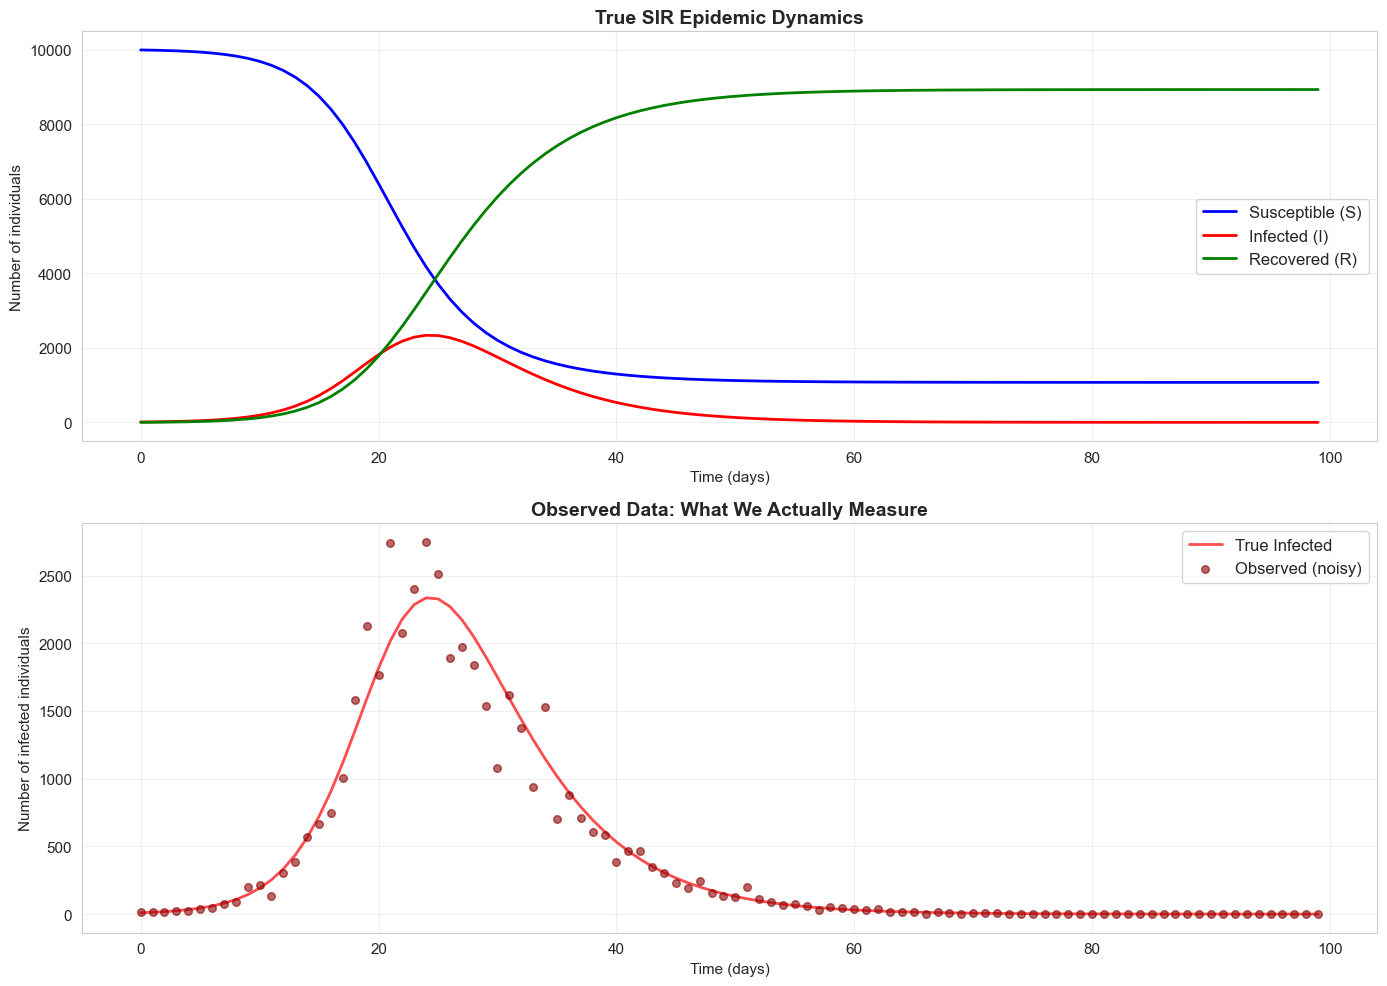


KEY INSIGHT: Data-to-Model Connection
The bottom plot shows what we typically observe in real epidemics:
- RED LINE: True underlying epidemic curve (unknown in practice)
- RED DOTS: Noisy observations (what we actually measure)

Our goal with PyMC:
1. Use the noisy observations to infer β and γ
2. Reconstruct the true epidemic curve with uncertainty bounds
3. Make predictions about future epidemic trajectory


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: All compartments (true values)
ax = axes[0]
ax.plot(t, S_true, 'b-', label='Susceptible (S)', linewidth=2)
ax.plot(t, I_true, 'r-', label='Infected (I)', linewidth=2)
ax.plot(t, R_true, 'g-', label='Recovered (R)', linewidth=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Number of individuals')
ax.set_title('True SIR Epidemic Dynamics', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 2: True vs Observed Infected
ax = axes[1]
ax.plot(t, I_true, 'r-', label='True Infected', linewidth=2, alpha=0.7)
ax.scatter(t, I_observed, c='darkred', s=30, alpha=0.6, label='Observed (noisy)', zorder=3)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Number of infected individuals')
ax.set_title('Observed Data: What We Actually Measure', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: Data-to-Model Connection")
print("="*60)
print("The bottom plot shows what we typically observe in real epidemics:")
print("- RED LINE: True underlying epidemic curve (unknown in practice)")
print("- RED DOTS: Noisy observations (what we actually measure)")
print("\nOur goal with PyMC:")
print("1. Use the noisy observations to infer β and γ")
print("2. Reconstruct the true epidemic curve with uncertainty bounds")
print("3. Make predictions about future epidemic trajectory")
print("="*60)

## Step 4: Set Up the PyMC Model

Now for the core of Bayesian inference! We'll set up a PyMC model that:

1. **Defines priors** on unknown parameters (β, γ, I₀)
2. **Solves the ODEs** at each MCMC iteration
3. **Connects ODE solutions to data** via a likelihood function

### Prior Choices:
- **β ~ Gamma(2, 4)**: Weakly informative prior centered around 0.5
- **γ ~ Gamma(2, 10)**: Weakly informative prior centered around 0.2
- **I₀ ~ Gamma(2, 0.2)**: Prior for initial infected (centered around 10)
- **ϕ ~ HalfNormal(10)**: Overdispersion parameter for Negative Binomial

### Likelihood:
We use a **Negative Binomial** likelihood to handle overdispersion:
$$
\text{Infected}_{\text{observed}} \sim \text{NegativeBinomial}(\mu=I(t), \alpha=\phi)
$$

In [7]:
# We need to create a PyTensor Op for the ODE solver
# This allows PyMC to call the ODE solver during sampling

@as_op(itypes=[pt.dscalar, pt.dscalar, pt.dscalar], otypes=[pt.dvector])
def solve_sir_pytensor(beta, gamma, I0):
    """
    PyTensor operation to solve SIR model.
    Returns only the infected time series.
    """
    solution = solve_sir(t, beta, gamma, N, I0, R0_true)
    return solution[:, 1]  # Return infected compartment (column 1)


print("Setting up PyMC model...")
print("This may take a moment as we define the structure.\n")

with pm.Model() as sir_model:
    # Priors for unknown parameters
    beta = pm.Gamma('beta', alpha=2, beta=4)  # Transmission rate
    gamma = pm.Gamma('gamma', alpha=2, beta=10)  # Recovery rate
    I0 = pm.Gamma('I0', alpha=2, beta=0.2)  # Initial infected
    
    # Overdispersion parameter for Negative Binomial
    phi = pm.HalfNormal('phi', sigma=10)
    
    # Solve ODEs to get model predictions
    I_model = solve_sir_pytensor(beta, gamma, I0)
    
    # Convert to NegativeBinomial parameterization
    # NegativeBinomial uses mu (mean) and alpha (dispersion)
    mu = I_model
    alpha = phi
    
    # Likelihood: connect model predictions to observed data
    I_obs = pm.NegativeBinomial(
        'I_obs',
        mu=mu,
        alpha=alpha,
        observed=I_observed
    )
    
    # Compute R0 as a deterministic variable
    R0 = pm.Deterministic('R0', beta / gamma)

print("Model structure defined successfully!")

# Optional: visualize model structure (requires graphviz)
try:
    print("\nModel graph:")
    display(pm.model_to_graphviz(sir_model))
except Exception as e:
    print("\nNote: Model graph visualization requires graphviz.")
    print("To install: pip install graphviz (and system graphviz package)")
    print("Skipping visualization - model is ready to use!")

Setting up PyMC model...
This may take a moment as we define the structure.

Model structure defined successfully!

Model graph:


/var/folders/xg/fw6tfd8s6bjf68kygkp3x3k80000gq/T/ipykernel_17633/700559682.py:4: FutureWarning: pytensor.as_op is deprecated and will be removed in a future release. Please use pytensor.wrap_py instead.
  @as_op(itypes=[pt.dscalar, pt.dscalar, pt.dscalar], otypes=[pt.dvector])


ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

## Step 5: Sample from the Posterior

Now we run the MCMC sampler to explore the posterior distribution of parameters given the data.

We'll use the NUTS (No-U-Turn Sampler) algorithm, which is particularly effective for continuous parameters.

**Note**: This may take a few minutes depending on your machine.

In [8]:
print("Starting MCMC sampling...")
print("This will take a few minutes. Progress bar will appear below.\n")

with sir_model:
    # Sample from posterior
    trace = pm.sample(
        draws=1000,
        tune=1000,
        cores=4,
        target_accept=0.95,
        return_inferencedata=True,
        random_seed=42
    )

print("\n" + "="*60)
print("Sampling complete!")
print("="*60)

Starting MCMC sampling...
This will take a few minutes. Progress bar will appear below.



Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CompoundStep
>>Slice: [beta]
>>Slice: [gamma]
>>Slice: [I0]
>NUTS: [phi]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details



Sampling complete!


## Step 6: Examine Posterior Distributions

Let's examine the posterior distributions of our inferred parameters and compare them to the true values.

In [9]:
# Print summary statistics
print("\nPosterior Summary Statistics:")
print("="*80)
summary = az.summary(trace, var_names=['beta', 'gamma', 'I0', 'phi', 'R0'])
print(summary)

print("\n" + "="*80)
print("Comparison with True Values:")
print("="*80)
print(f"Beta:  True = {beta_true:.3f}, Posterior mean = {trace.posterior['beta'].mean().values:.3f}")
print(f"Gamma: True = {gamma_true:.3f}, Posterior mean = {trace.posterior['gamma'].mean().values:.3f}")
print(f"I0:    True = {I0_true:.1f}, Posterior mean = {trace.posterior['I0'].mean().values:.1f}")
print(f"R0:    True = {beta_true/gamma_true:.2f}, Posterior mean = {trace.posterior['R0'].mean().values:.2f}")
print("="*80)

# Check diagnostics
print("\nDiagnostics:")
print(f"All rhat values < 1.01: {(summary['r_hat'] < 1.01).all()}")
print(f"All ESS bulk > 400: {(summary['ess_bulk'] > 400).all()}")


Posterior Summary Statistics:
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta    0.504  0.006   0.494    0.515      0.000    0.000     445.0    1024.0   
gamma   0.199  0.005   0.190    0.209      0.000    0.000    1285.0    1979.0   
I0      9.190  1.027   7.298   11.099      0.048    0.023     462.0     950.0   
phi    20.151  3.767  13.259   27.400      0.105    0.077    1246.0     902.0   
R0      2.535  0.078   2.387    2.684      0.003    0.001     695.0    1376.0   

       r_hat  
beta    1.01  
gamma   1.00  
I0      1.01  
phi     1.00  
R0      1.01  

Comparison with True Values:
Beta:  True = 0.500, Posterior mean = 0.504
Gamma: True = 0.200, Posterior mean = 0.199
I0:    True = 10.0, Posterior mean = 9.2
R0:    True = 2.50, Posterior mean = 2.54

Diagnostics:
All rhat values < 1.01: False
All ESS bulk > 400: True


/var/folders/xg/fw6tfd8s6bjf68kygkp3x3k80000gq/T/ipykernel_17633/1340422371.py:32: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/trobacker/GitHub/pymc_modeling/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


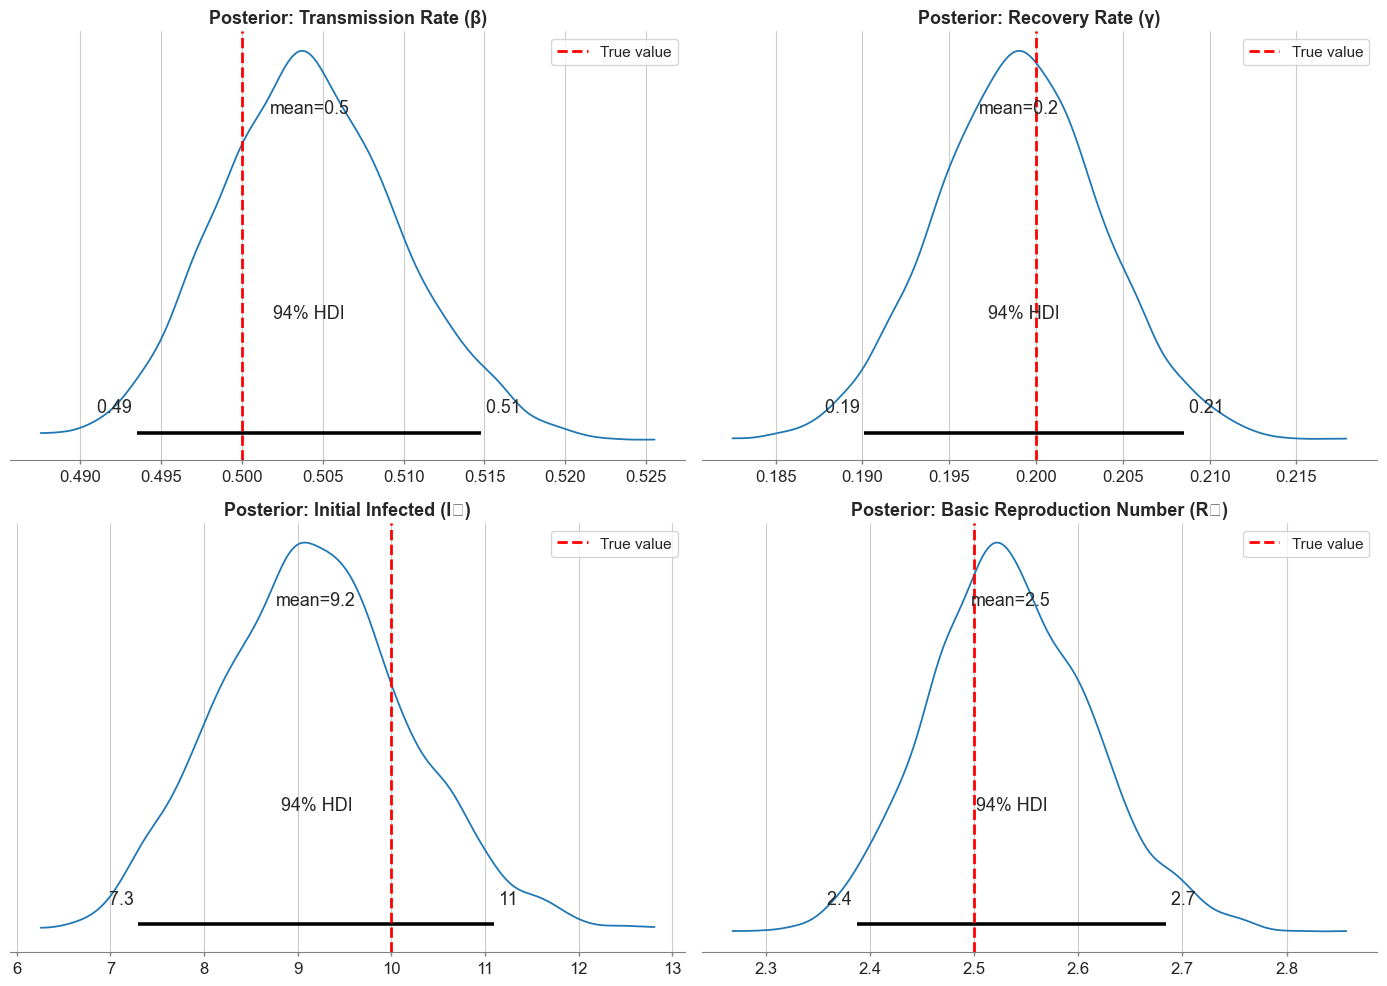


The red dashed lines show the true parameter values.
The posterior distributions should be centered near these true values!


In [10]:
# Plot posterior distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Beta
ax = axes[0, 0]
az.plot_posterior(trace, var_names=['beta'], ax=ax, textsize=12)
ax.axvline(beta_true, color='red', linestyle='--', linewidth=2, label='True value')
ax.set_title('Posterior: Transmission Rate (β)', fontsize=13, fontweight='bold')
ax.legend()

# Gamma
ax = axes[0, 1]
az.plot_posterior(trace, var_names=['gamma'], ax=ax, textsize=12)
ax.axvline(gamma_true, color='red', linestyle='--', linewidth=2, label='True value')
ax.set_title('Posterior: Recovery Rate (γ)', fontsize=13, fontweight='bold')
ax.legend()

# I0
ax = axes[1, 0]
az.plot_posterior(trace, var_names=['I0'], ax=ax, textsize=12)
ax.axvline(I0_true, color='red', linestyle='--', linewidth=2, label='True value')
ax.set_title('Posterior: Initial Infected (I₀)', fontsize=13, fontweight='bold')
ax.legend()

# R0
ax = axes[1, 1]
az.plot_posterior(trace, var_names=['R0'], ax=ax, textsize=12)
ax.axvline(beta_true/gamma_true, color='red', linestyle='--', linewidth=2, label='True value')
ax.set_title('Posterior: Basic Reproduction Number (R₀)', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print("\nThe red dashed lines show the true parameter values.")
print("The posterior distributions should be centered near these true values!")

## Step 7: Trace Plots (MCMC Diagnostics)

Trace plots help us assess whether the MCMC chains have converged and are mixing well.

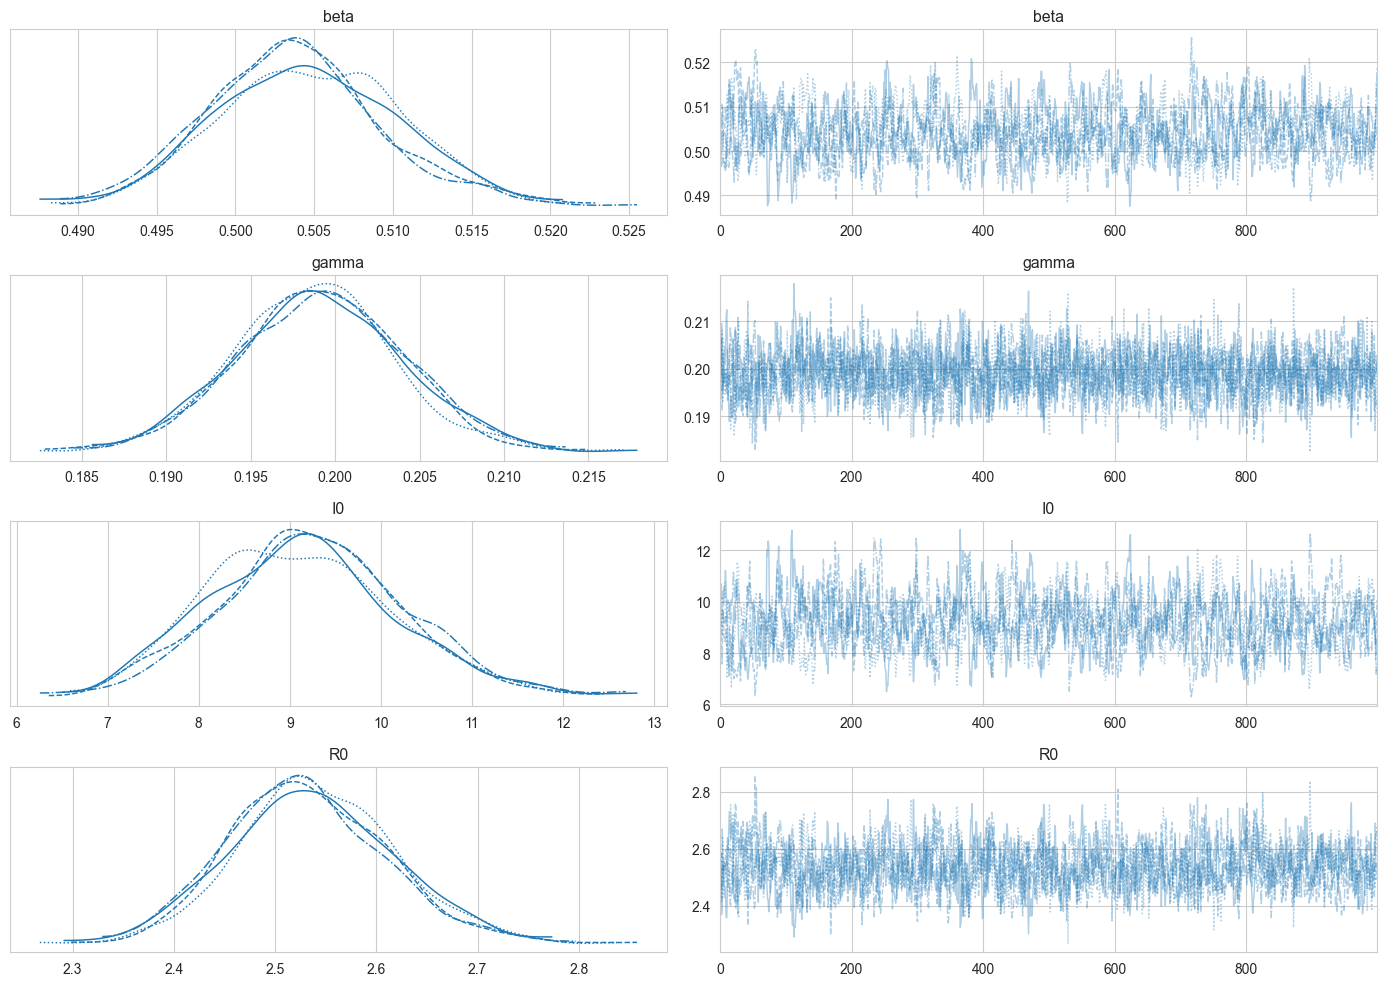


What to look for in trace plots:
- LEFT: Posterior distributions (should look smooth)
- RIGHT: Chain traces (should look like 'hairy caterpillars')
- All chains should overlap and explore the same regions
- No trends or drift in the traces


In [11]:
# Plot traces
az.plot_trace(
    trace,
    var_names=['beta', 'gamma', 'I0', 'R0'],
    figsize=(14, 10)
)
plt.tight_layout()
plt.show()

print("\nWhat to look for in trace plots:")
print("- LEFT: Posterior distributions (should look smooth)")
print("- RIGHT: Chain traces (should look like 'hairy caterpillars')")
print("- All chains should overlap and explore the same regions")
print("- No trends or drift in the traces")

## Step 8: Posterior Predictive Checks

Now let's generate predictions from our fitted model and compare them to the observed data. This is crucial for validating that our model captures the data well.

In [12]:
# Sample from posterior predictive distribution
print("Generating posterior predictive samples...\n")

with sir_model:
    post_pred = pm.sample_posterior_predictive(
        trace,
        random_seed=42
    )

print("Posterior predictive sampling complete!")

Sampling: [I_obs]


Output()

Generating posterior predictive samples...



Posterior predictive sampling complete!


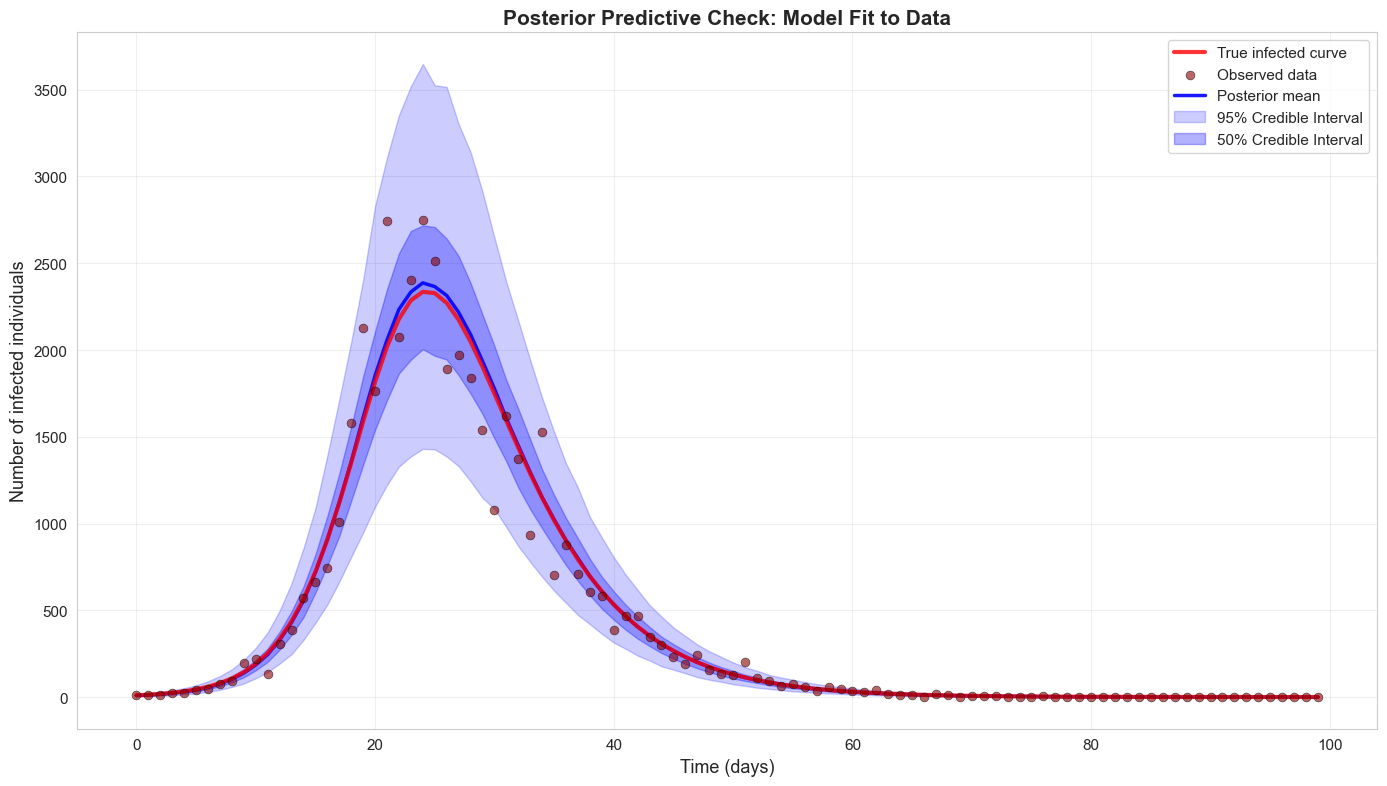


INTERPRETING THE POSTERIOR PREDICTIVE CHECK
This plot shows how well our fitted model captures the observed data:

- RED LINE: True epidemic curve (unknown in real applications)
- RED DOTS: Observed data points (what we actually measured)
- BLUE LINE: Posterior mean prediction from fitted model
- BLUE SHADING: Uncertainty in our predictions (95% credible interval)

A good fit means:
1. Most observed data points fall within the credible intervals
2. The posterior mean follows the general trend of the data
3. The model captures the epidemic peak and overall dynamics


In [13]:
# Extract posterior predictive samples
I_pp = post_pred.posterior_predictive['I_obs'].values  # Shape: (chains, draws, time)

# Flatten chains and draws
I_pp_flat = I_pp.reshape(-1, len(t))  # Shape: (total_samples, time)

# Compute credible intervals
I_mean = I_pp_flat.mean(axis=0)
I_lower = np.percentile(I_pp_flat, 2.5, axis=0)
I_upper = np.percentile(I_pp_flat, 97.5, axis=0)
I_lower_50 = np.percentile(I_pp_flat, 25, axis=0)
I_upper_50 = np.percentile(I_pp_flat, 75, axis=0)

# Plot posterior predictive checks
fig, ax = plt.subplots(figsize=(14, 8))

# Plot true curve
ax.plot(t, I_true, 'r-', linewidth=3, label='True infected curve', alpha=0.8, zorder=4)

# Plot observed data
ax.scatter(t, I_observed, c='darkred', s=40, alpha=0.6, 
           label='Observed data', zorder=5, edgecolors='black', linewidths=0.5)

# Plot posterior predictive mean and intervals
ax.plot(t, I_mean, 'b-', linewidth=2.5, label='Posterior mean', alpha=0.9, zorder=3)
ax.fill_between(t, I_lower, I_upper, color='blue', alpha=0.2, 
                label='95% Credible Interval', zorder=1)
ax.fill_between(t, I_lower_50, I_upper_50, color='blue', alpha=0.3, 
                label='50% Credible Interval', zorder=2)

ax.set_xlabel('Time (days)', fontsize=13)
ax.set_ylabel('Number of infected individuals', fontsize=13)
ax.set_title('Posterior Predictive Check: Model Fit to Data', 
             fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("INTERPRETING THE POSTERIOR PREDICTIVE CHECK")
print("="*80)
print("This plot shows how well our fitted model captures the observed data:")
print("\n- RED LINE: True epidemic curve (unknown in real applications)")
print("- RED DOTS: Observed data points (what we actually measured)")
print("- BLUE LINE: Posterior mean prediction from fitted model")
print("- BLUE SHADING: Uncertainty in our predictions (95% credible interval)")
print("\nA good fit means:")
print("1. Most observed data points fall within the credible intervals")
print("2. The posterior mean follows the general trend of the data")
print("3. The model captures the epidemic peak and overall dynamics")
print("="*80)

## Step 9: Visualize Uncertainty in Full SIR Trajectories

Finally, let's visualize the full SIR trajectories (S, I, R) with uncertainty bands. This shows how parameter uncertainty propagates through the entire epidemic.

In [14]:
# Sample 200 parameter sets from posterior
n_samples = 200
beta_samples = trace.posterior['beta'].values.flatten()
gamma_samples = trace.posterior['gamma'].values.flatten()
I0_samples = trace.posterior['I0'].values.flatten()

# Randomly select n_samples
indices = np.random.choice(len(beta_samples), size=n_samples, replace=False)

# Store trajectories
S_trajectories = []
I_trajectories = []
R_trajectories = []

print(f"Generating {n_samples} epidemic trajectories from posterior...\n")

for idx in indices:
    beta_sample = beta_samples[idx]
    gamma_sample = gamma_samples[idx]
    I0_sample = I0_samples[idx]
    
    solution = solve_sir(t, beta_sample, gamma_sample, N, I0_sample, R0_true)
    S_trajectories.append(solution[:, 0])
    I_trajectories.append(solution[:, 1])
    R_trajectories.append(solution[:, 2])

S_trajectories = np.array(S_trajectories)
I_trajectories = np.array(I_trajectories)
R_trajectories = np.array(R_trajectories)

print("Trajectory generation complete!")

Generating 200 epidemic trajectories from posterior...

Trajectory generation complete!


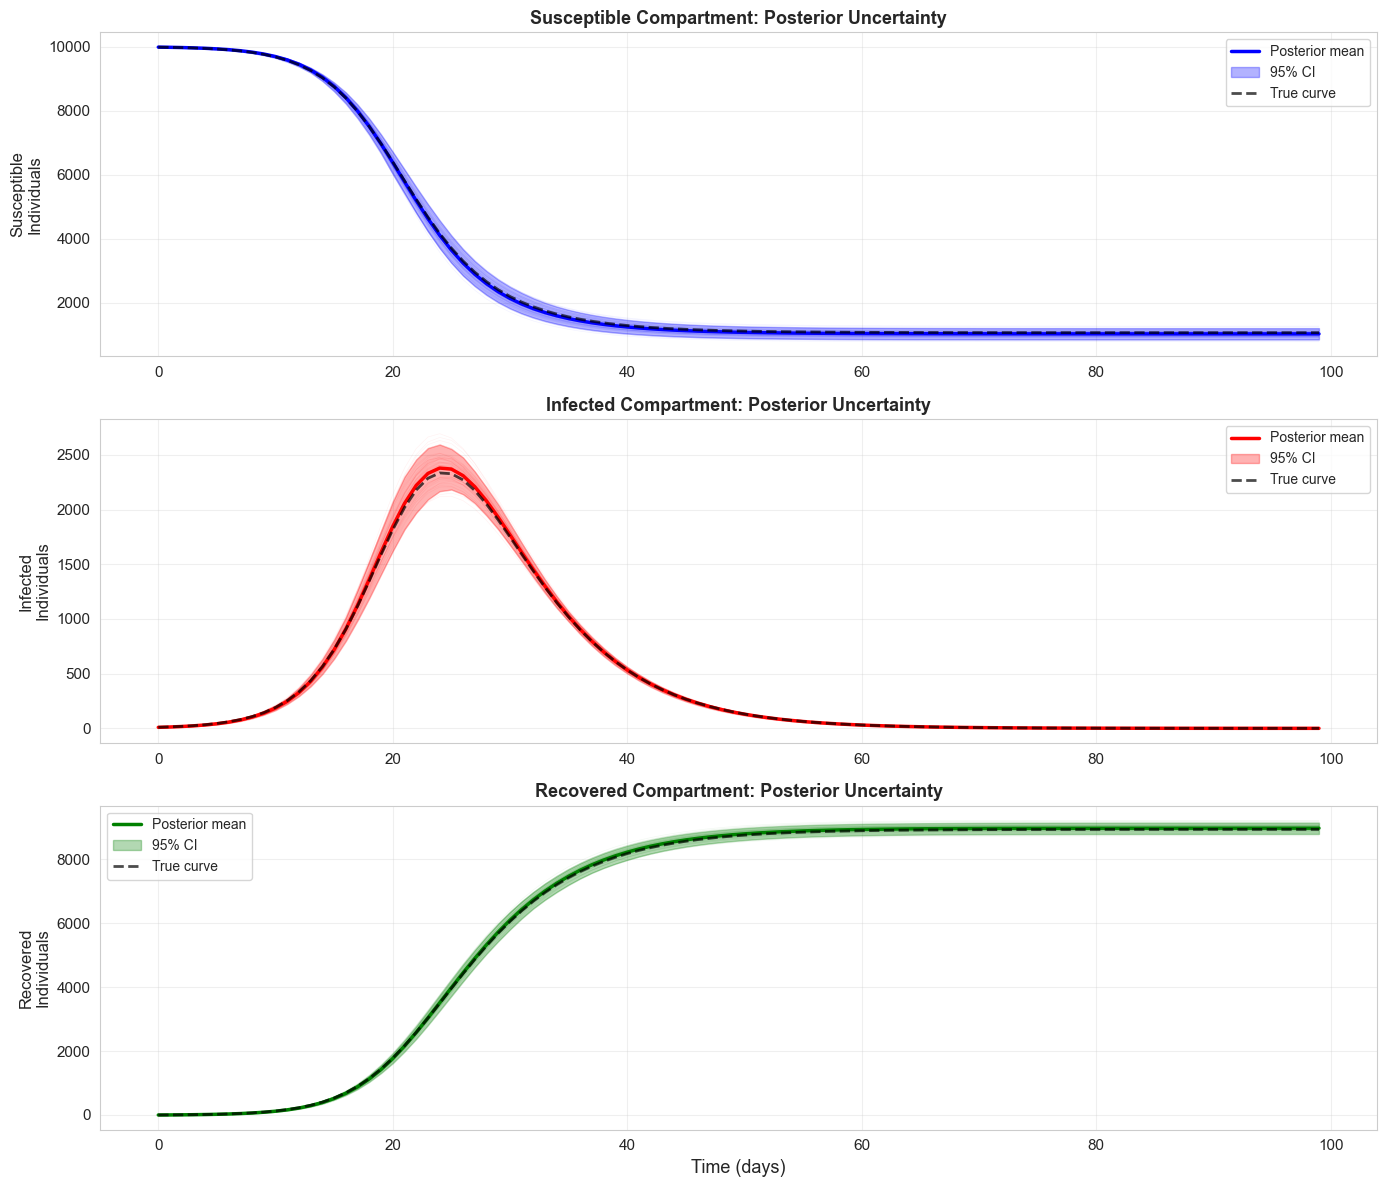


UNCERTAINTY PROPAGATION IN EPIDEMIC TRAJECTORIES
These plots show how uncertainty in parameters (β, γ, I₀) translates
into uncertainty about the entire epidemic trajectory.

Key observations:
- Light colored lines: Individual samples from posterior
- Solid colored line: Posterior mean trajectory
- Shaded region: 95% credible interval
- Black dashed line: True curve

Notice that uncertainty is largest around the epidemic peak!


In [15]:
# Plot full SIR trajectories with uncertainty
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

compartments = [
    ('Susceptible', S_trajectories, S_true, 'blue'),
    ('Infected', I_trajectories, I_true, 'red'),
    ('Recovered', R_trajectories, R_true, 'green')
]

for ax, (name, trajectories, true_vals, color) in zip(axes, compartments):
    # Plot sample trajectories
    for traj in trajectories[:50]:  # Plot first 50 samples
        ax.plot(t, traj, color=color, alpha=0.05, linewidth=0.5)
    
    # Plot mean and credible intervals
    mean_traj = trajectories.mean(axis=0)
    lower = np.percentile(trajectories, 2.5, axis=0)
    upper = np.percentile(trajectories, 97.5, axis=0)
    
    ax.plot(t, mean_traj, color=color, linewidth=2.5, label='Posterior mean', zorder=3)
    ax.fill_between(t, lower, upper, color=color, alpha=0.3, 
                    label='95% CI', zorder=2)
    ax.plot(t, true_vals, 'k--', linewidth=2, label='True curve', alpha=0.7, zorder=4)
    
    ax.set_ylabel(f'{name}\nIndividuals', fontsize=12)
    ax.set_title(f'{name} Compartment: Posterior Uncertainty', 
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (days)', fontsize=13)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("UNCERTAINTY PROPAGATION IN EPIDEMIC TRAJECTORIES")
print("="*80)
print("These plots show how uncertainty in parameters (β, γ, I₀) translates")
print("into uncertainty about the entire epidemic trajectory.")
print("\nKey observations:")
print("- Light colored lines: Individual samples from posterior")
print("- Solid colored line: Posterior mean trajectory")
print("- Shaded region: 95% credible interval")
print("- Black dashed line: True curve")
print("\nNotice that uncertainty is largest around the epidemic peak!")
print("="*80)

## Step 10: Parameter Correlations

Let's examine correlations between parameters. Understanding these relationships helps interpret the model.

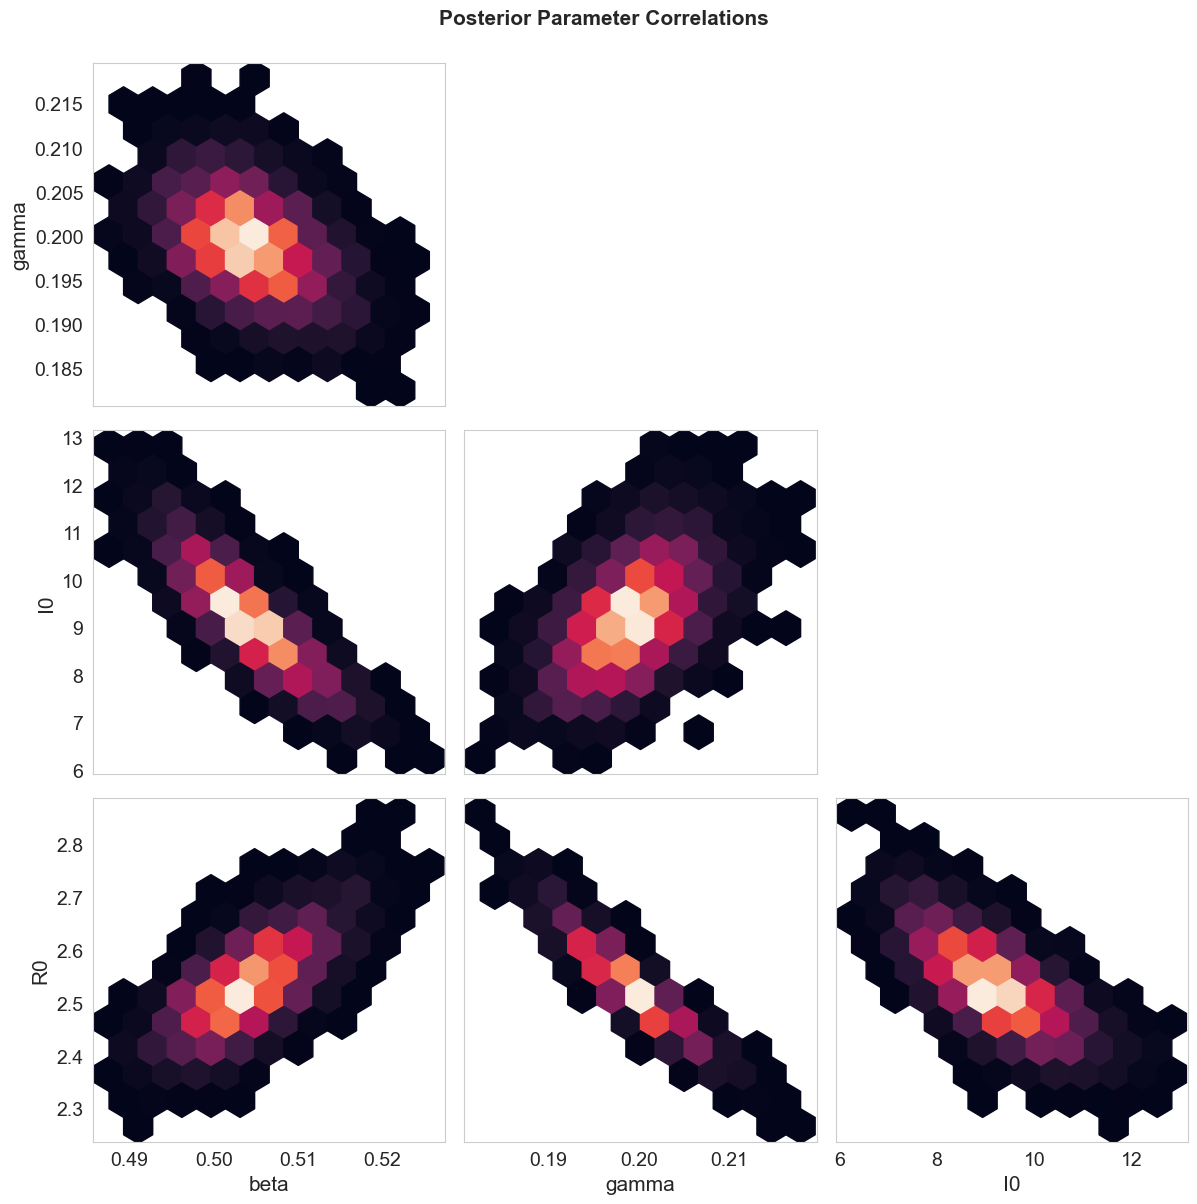


This pair plot shows relationships between parameters:
- Diagonal: Marginal distributions of each parameter
- Off-diagonal: Joint distributions (correlations)
- Look for strong correlations that might indicate identifiability issues


In [16]:
# Pair plot of parameters
az.plot_pair(
    trace,
    var_names=['beta', 'gamma', 'I0', 'R0'],
    kind='hexbin',
    figsize=(12, 12),
    divergences=True
)
plt.suptitle('Posterior Parameter Correlations', fontsize=15, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

print("\nThis pair plot shows relationships between parameters:")
print("- Diagonal: Marginal distributions of each parameter")
print("- Off-diagonal: Joint distributions (correlations)")
print("- Look for strong correlations that might indicate identifiability issues")

## Summary: Key Takeaways

### What We Learned:

1. **SIR Model Structure**: Classic epidemic model with S, I, R compartments governed by ODEs

2. **Data-to-Model Connection**: 
   - We observe noisy counts of infected individuals
   - The model connects these observations to underlying ODE dynamics
   - Bayesian inference lets us infer parameters (β, γ) from noisy data

3. **PyMC Workflow**:
   - Define priors on unknown parameters
   - Embed ODE solver in the model using PyTensor operations
   - Connect ODE solutions to data via likelihood function
   - Use MCMC (NUTS) to sample from posterior

4. **Model Validation**:
   - Check MCMC diagnostics (rhat, ESS, traces)
   - Compare posterior distributions to true values
   - Perform posterior predictive checks
   - Visualize uncertainty in predictions

5. **Practical Insights**:
   - Parameter uncertainty propagates through the entire epidemic trajectory
   - Uncertainty is often largest near the epidemic peak
   - The model can recover true parameters from noisy observations
   - Credible intervals quantify our uncertainty about future epidemic dynamics

### Extensions to Explore:

- More complex models (SEIR, age-structured, spatial)
- Time-varying parameters (changing transmission rates)
- Different observation models (deaths, hospitalizations)
- Forecasting beyond observed data
- Model comparison using LOO or WAIC
- Real-world data applications

## Additional Resources

- PyMC Documentation: https://www.pymc.io
- ArviZ Documentation: https://arviz-devs.github.io
- Epidemic Modeling: "Infectious Diseases of Humans" by Anderson & May
- Bayesian Workflow: https://arxiv.org/abs/2011.01808